In [3]:
import os
import sys

# Resolve repo root whether cwd is repo root, scripts/, or a stage subdirectory.
cwd = os.getcwd()
if os.path.basename(cwd) == "orb-selection":
    repo_root = cwd
elif os.path.basename(os.path.dirname(cwd)) == "orb-selection":
    repo_root = os.path.dirname(cwd)
elif os.path.basename(os.path.dirname(os.path.dirname(cwd))) == "orb-selection":
    repo_root = os.path.dirname(os.path.dirname(cwd))
else:
    repo_root = cwd

src_path = os.path.join(repo_root, "src")
stage05_path = os.path.join(repo_root, "scripts", "05_permulation_loss_dup")
for path in (src_path, stage05_path):
    if path not in sys.path:
        sys.path.insert(0, path)

print(f"Using src path: {src_path}")
print(f"Using stage-05 path: {stage05_path}")

# Import modules
import odds_ratio_test as ort
from id_converter import convert_hogs_to_locs

%load_ext autoreload

Using src path: /Users/calvin/orb-selection/src
Using stage-05 path: /Users/calvin/orb-selection/scripts/05_permulation_loss_dup
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Loss

84 species total, 30 foreground, 54 background                                                  
Mean: -0.71, Stddev: 1.60, Count: 5293                                                          


/Users/calvin/orb-selection/scripts/05_permulation_loss_dup/odds_ratio_test.py:279: RuntimeWarning: invalid value encountered in log
  return -np.nansum(np.log(p), axis=0)


Optimized triple Gaussian parameters:                                                           
  weight_1: -0.000                                                                              
  mean_1: -2.092                                                                                
  stddev_1: 1.196                                                                               
  weight_2: 0.827                                                                               
  mean_2: -1.084                                                                                
  stddev_2: 1.242                                                                               
  mean_3: 1.070                                                                                 
  stddev_3: 1.894                                                                               
                                                                                                
LAUNCHING PERMUTATION TEST    

  0%|          | 0/10000 [00:00<?, ?it/s]

Permutation counter for MEAN (single Gaussian): 4563                                            
Permutation counter for MEAN 1 (triple Gaussian): 1474                                          
Permutation counter for MEAN 2 (triple Gaussian): 2062                                          
Permutation counter for MEAN 3 (triple Gaussian): 3873                                          
                                                                                                
Filtering log odds ratio results df for occupancy >= 42, <= 81 with alternative hypothesis      
'two-tailed' and log odds ratio threshold [-3.42123929  2.90652988]                             
                                                                                                
Filtering for presence of Uloborus_diversus                                                     
                                                                                                
*********************** RESULT

Processing HOGs:   0%|          | 0/293 [00:00<?, ?it/s]

Results files saved to                                                                          
/Users/calvin/orb-selection/results/odds_ratio_test/Results_Apr07/Run3_Loss_LT_42-81_10000x     
                                                                                                
Files include:                                                                                  
	 1. [test]_permutation_results.png: True LORs distribution                                     
		vs. average permuted distribution                                                             
	 2. [test]_permutation_stats_dists.png: Histograms of the                                      
		means, standard deviations, and skews of all 10,000                                           
		permuted LOR distributions                                                                    
	 3. [test]_results_summary.txt: Text file summarizing results                                  
	 4. [test].pkl: Pickle file s

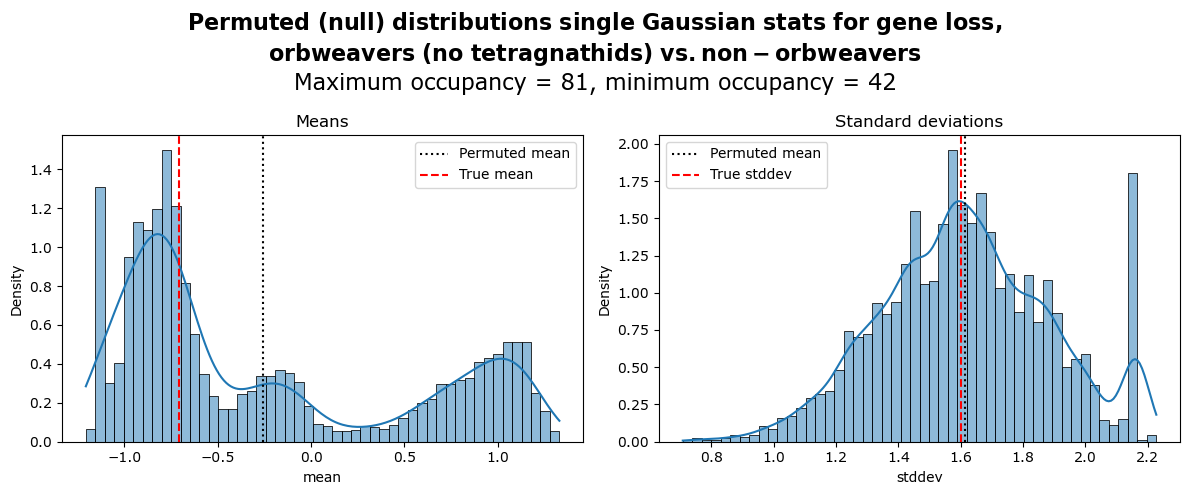

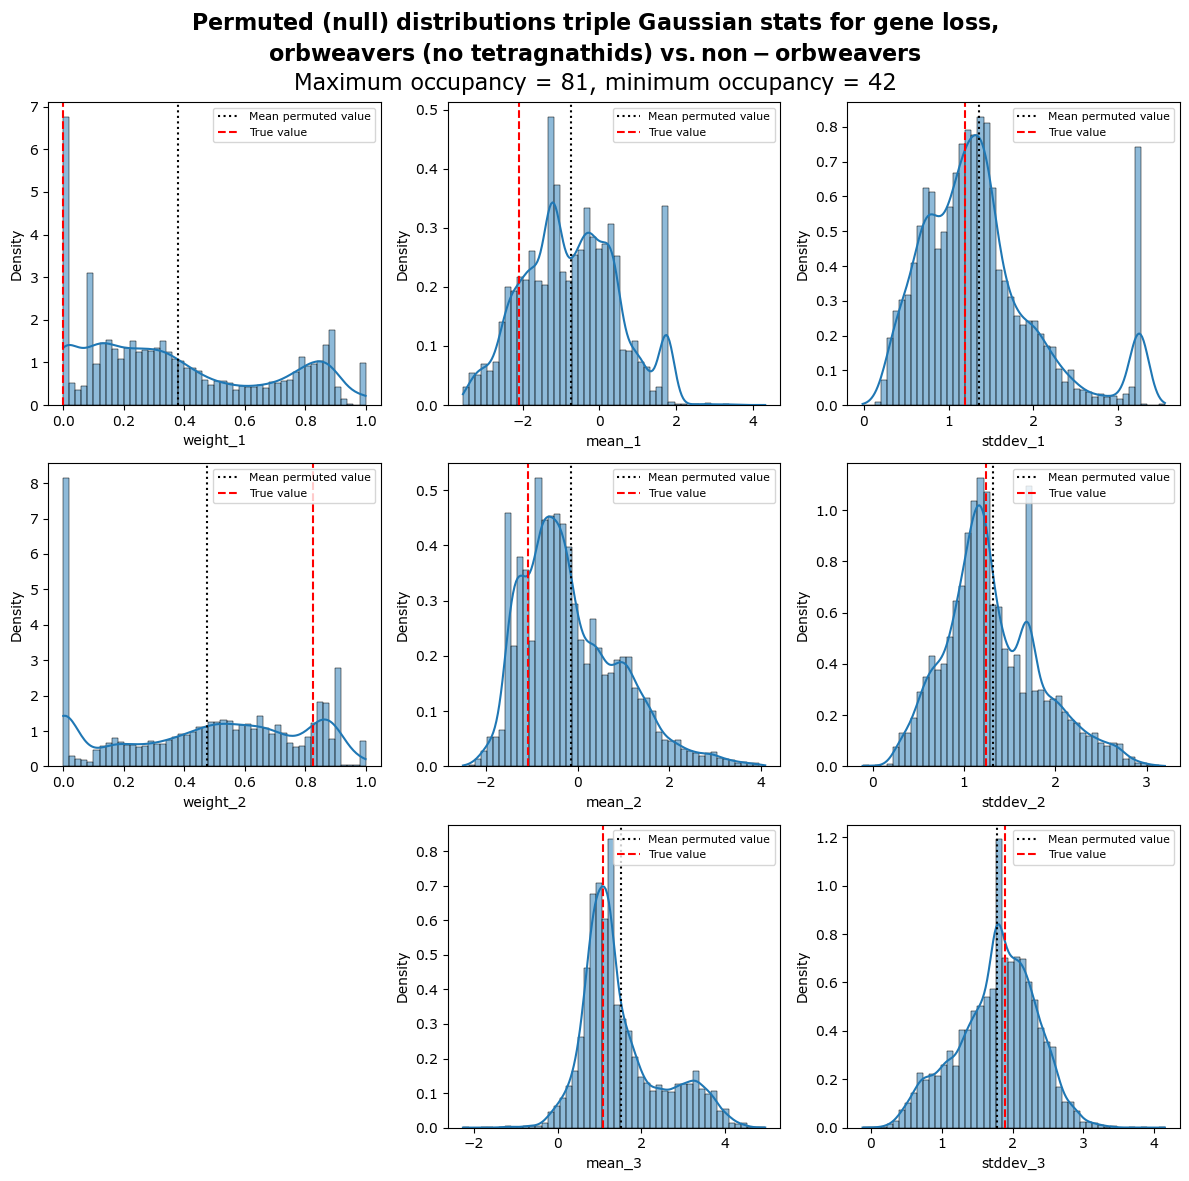

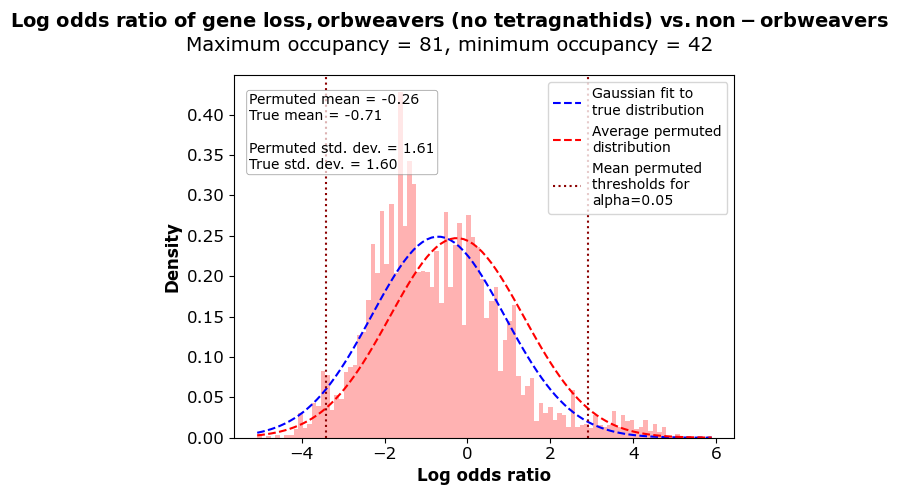

In [4]:
%autoreload 2
loss_lt_42_81 = ort.odds_ratio_test(
    test="loss",
    occupancy_threshold=42,
    max_occ=81,
    alternative="less",
    species_of_interest="Uloborus_diversus",
    results_dir=f"results/odds_ratio_test",
    fg_name='orbweavers (no tetragnathids)',
    bg_name='non-orbweavers',
    foreground_list_filename="data/orbweavers-list-no-tetragnathids.txt",
    background_list_filename="data/non-orb-weavers-list.txt",
    permulations_tip_values_csv="data/perms_tip_values_no_tetragnathids.csv",
    save_two_tailed_hits=True,
)

## Duplication

84 species total, 30 foreground, 54 background                                                  
Mean: -0.04, Stddev: 1.07, Count: 8063                                                          


/Users/calvin/orb-selection/scripts/05_permulation_loss_dup/odds_ratio_test.py:279: RuntimeWarning: invalid value encountered in log
  return -np.nansum(np.log(p), axis=0)


Optimized triple Gaussian parameters:                                                           
  weight_1: 0.401                                                                               
  mean_1: -0.560                                                                                
  stddev_1: 1.002                                                                               
  weight_2: 0.412                                                                               
  mean_2: -0.008                                                                                
  stddev_2: 0.701                                                                               
  mean_3: 1.007                                                                                 
  stddev_3: 1.120                                                                               
                                                                                                
LAUNCHING PERMUTATION TEST    

  0%|          | 0/10000 [00:00<?, ?it/s]

Permutation counter for MEAN (single Gaussian): 5033                                            
Permutation counter for MEAN 1 (triple Gaussian): 3309                                          
Permutation counter for MEAN 2 (triple Gaussian): 6974                                          
Permutation counter for MEAN 3 (triple Gaussian): 3018                                          
                                                                                                
Filtering log odds ratio results df for occupancy >= 42, <= 84 with alternative hypothesis      
'two-tailed' and log odds ratio threshold [-2.12630468  2.08376219]                             
                                                                                                
Filtering for presence of Uloborus_diversus                                                     
                                                                                                
*********************** RESULT

Processing HOGs:   0%|          | 0/314 [00:00<?, ?it/s]

Results files saved to                                                                          
/Users/calvin/orb-selection/results/odds_ratio_test/Results_Apr07/Run4_Dup_RT_42-max_10000x     
                                                                                                
Files include:                                                                                  
	 1. [test]_permutation_results.png: True LORs distribution                                     
		vs. average permuted distribution                                                             
	 2. [test]_permutation_stats_dists.png: Histograms of the                                      
		means, standard deviations, and skews of all 10,000                                           
		permuted LOR distributions                                                                    
	 3. [test]_results_summary.txt: Text file summarizing results                                  
	 4. [test].pkl: Pickle file s

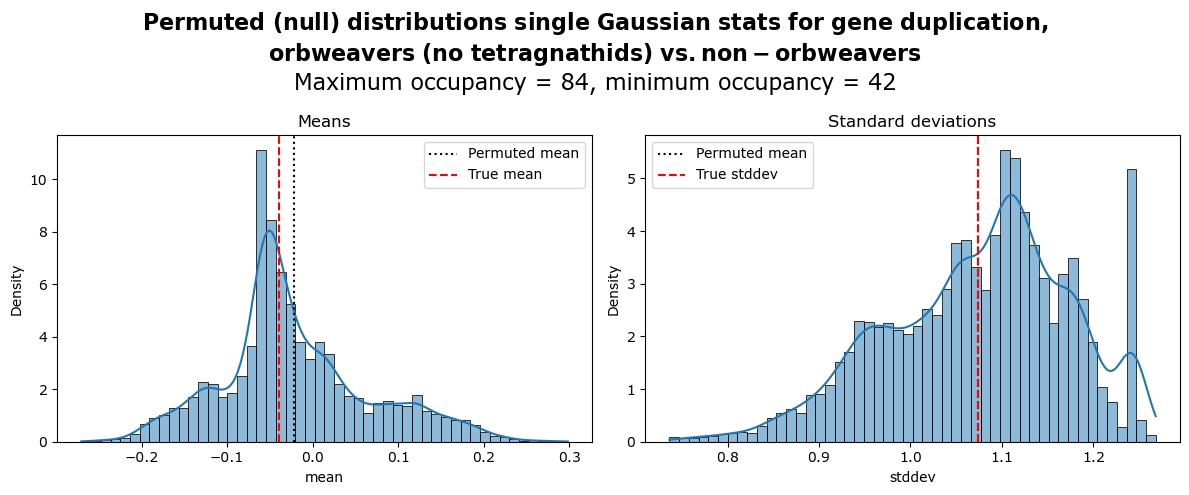

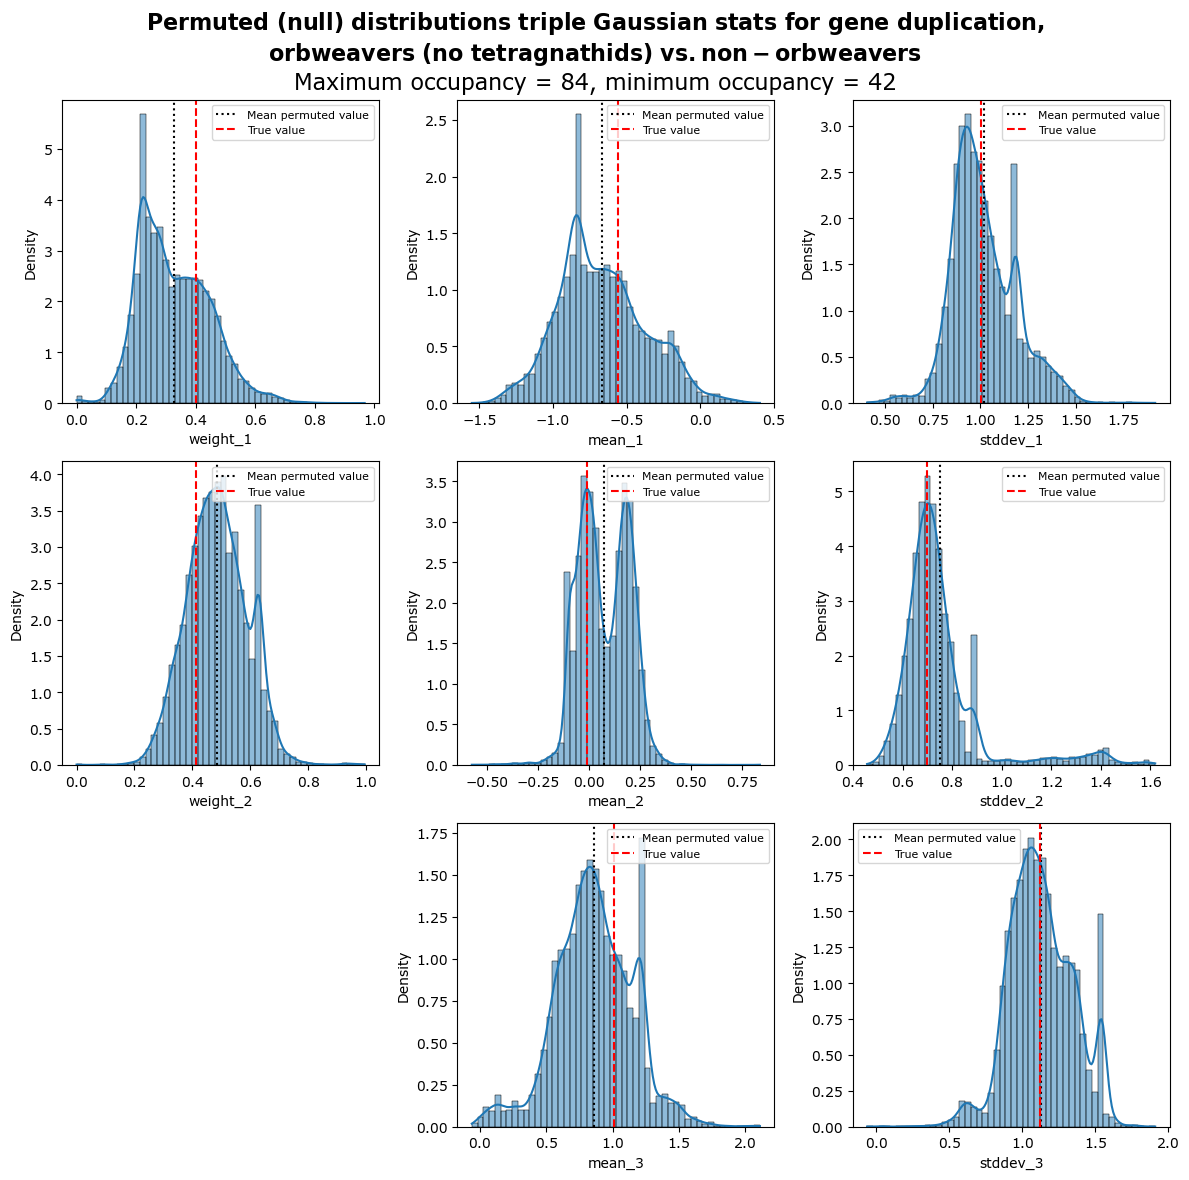

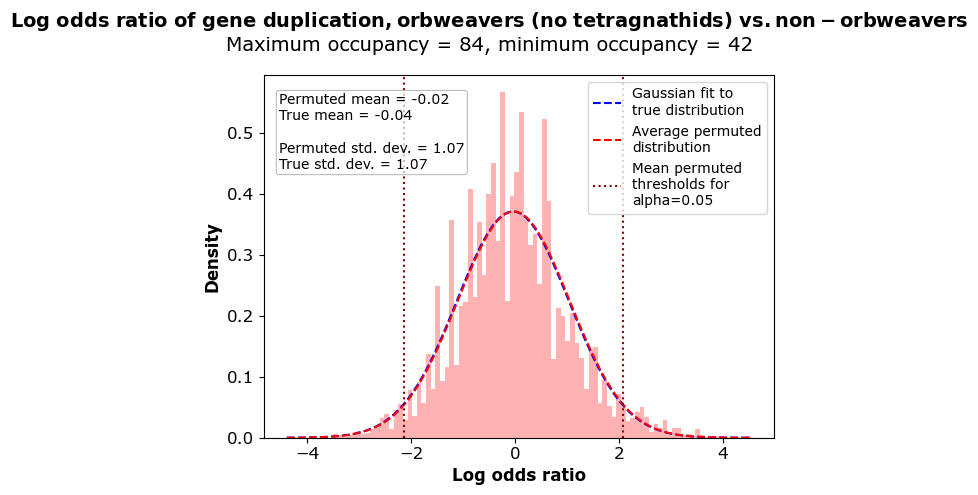

In [5]:
%autoreload 2
dup_rt_42_84 = ort.odds_ratio_test(
    test="duplication",
    occupancy_threshold=42,
    alternative="greater",
    species_of_interest="Uloborus_diversus",
    results_dir=f"results/odds_ratio_test",
    fg_name='orbweavers (no tetragnathids)',
    bg_name='non-orbweavers',
    foreground_list_filename="data/orbweavers-list-no-tetragnathids.txt",
    background_list_filename="data/non-orb-weavers-list.txt",
    permulations_tip_values_csv="data/perms_tip_values_no_tetragnathids.csv",
    save_two_tailed_hits=True
)